# Data Loading

In [1]:
#importing libraries that are relevant, this will allow me to manipulate data and merge tables
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
from sklearn.neighbors import LocalOutlierFactor
import plotly.express as px

In [2]:
#naming my file as data1
#read the csv file
data1 = pd.read_csv('/content/dataset1.csv')

## Basic info on the data

In [3]:
#this function calls the first 10 instances from the dataset
data1.head(10)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
6,7,5,Graduate,No,8700000,33000000,4,678,22500000,14800000,29200000,4300000,Approved
7,8,2,Graduate,Yes,5700000,15000000,20,382,13200000,5700000,11800000,6000000,Rejected
8,9,0,Graduate,Yes,800000,2200000,20,782,1300000,800000,2800000,600000,Approved
9,10,5,Not Graduate,No,1100000,4300000,10,388,3200000,1400000,3300000,1600000,Rejected


In [4]:
data1.shape

(4269, 13)

In [5]:
#this function breaks down the types of data in the dataset
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [6]:
#basic stats
data1.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_id,4269.0,2.135000e+03,1.232498e+03,1.0,1068.0,2135.0,3202.0,4269.0
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0


In [7]:
#this function calls all the column names
data1.columns.tolist()

['loan_id',
 ' no_of_dependents',
 ' education',
 ' self_employed',
 ' income_annum',
 ' loan_amount',
 ' loan_term',
 ' cibil_score',
 ' residential_assets_value',
 ' commercial_assets_value',
 ' luxury_assets_value',
 ' bank_asset_value',
 ' loan_status']

In [8]:
#this function creates stats on the catagorical varaibles bin the dataset
#hence why it says object
data1.describe(include='object')

,education,self_employed,loan_status
count,4269,4269,4269
unique,2,2,2
top,Graduate,Yes,Approved
freq,2144,2150,2656


In [9]:
print(data1.head())

   loan_id   no_of_dependents      education  self_employed   income_annum  \
0        1                  2       Graduate             No        9600000   
1        2                  0   Not Graduate            Yes        4100000   
2        3                  3       Graduate             No        9100000   
3        4                  3       Graduate             No        8200000   
4        5                  5   Not Graduate            Yes        9800000   

    loan_amount   loan_term   cibil_score   residential_assets_value  \
0      29900000          12           778                    2400000   
1      12200000           8           417                    2700000   
2      29700000          20           506                    7100000   
3      30700000           8           467                   18200000   
4      24200000          20           382                   12400000   

    commercial_assets_value   luxury_assets_value   bank_asset_value  \
0                  1760000

In [10]:
data1.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


# Chckeing unique data values

In [11]:
data1.nunique()

,0
loan_id,4269
no_of_dependents,6
education,2
self_employed,2
income_annum,98
loan_amount,378
loan_term,10
cibil_score,601
residential_assets_value,278
commercial_assets_value,188


In [12]:
data1["loan_id"].unique()

array([   1,    2,    3, ..., 4267, 4268, 4269])

In [13]:
data1[" no_of_dependents"].unique()

array([2, 0, 3, 5, 4, 1])

In [14]:
data1[" education"].unique()

array([' Graduate', ' Not Graduate'], dtype=object)

In [15]:
data1[" self_employed"].unique()

array([' No', ' Yes'], dtype=object)

In [16]:
data1[" income_annum"].unique()

array([9600000, 4100000, 9100000, 8200000, 9800000, 4800000, 8700000,
       5700000,  800000, 1100000, 2900000, 6700000, 5000000, 1900000,
       4700000,  500000, 2700000, 6300000, 5800000, 6500000, 4900000,
       3100000, 2400000, 7000000, 9000000, 8400000, 1700000, 1600000,
       8000000, 3600000, 1500000, 7800000, 1400000, 4200000, 5500000,
       9500000, 7300000, 3800000, 5100000, 4300000, 9300000, 7400000,
       8500000, 8800000, 3300000, 3900000, 8300000, 5600000, 5300000,
       2600000,  700000, 3500000, 9900000, 3000000, 6800000, 2000000,
       1000000,  300000, 6600000, 9400000, 4400000,  400000, 6200000,
       9700000, 7100000,  600000, 7200000,  900000,  200000, 1800000,
       4600000, 2200000, 2500000, 8600000, 4000000, 5200000, 8900000,
       1300000, 4500000, 8100000, 9200000, 2800000, 7500000, 6400000,
       6900000, 7700000, 3200000, 7900000, 5900000, 3400000, 2100000,
       3700000, 5400000, 2300000, 7600000, 6000000, 6100000, 1200000])

In [17]:
data1[" loan_amount"].unique()

array([29900000, 12200000, 29700000, 30700000, 24200000, 13500000,
       33000000, 15000000,  2200000,  4300000, 11200000, 22700000,
       11600000, 31500000,  7400000, 10700000,  1600000,  9400000,
       10300000, 14600000, 19400000, 14000000, 25700000,  1400000,
        9800000,  9500000, 28100000,  5600000, 24000000, 25300000,
       12000000, 22000000, 11900000,  3400000,  6200000, 27200000,
        7700000,  5100000, 18100000, 24900000,  2300000, 13400000,
       27800000, 19100000, 20500000, 25400000, 24700000,  7600000,
       23000000, 19700000, 24500000, 10600000, 30500000, 18400000,
       18200000, 18900000, 28900000,  7500000, 12300000, 29100000,
       10100000, 12400000,  5000000,  1500000, 18600000, 18300000,
       16700000,  8400000,  6500000, 14800000, 33500000, 29400000,
        8900000, 31200000, 21200000,  8600000,  8200000,  3800000,
       28300000,  8000000, 37600000, 21100000, 20700000,  6400000,
        2000000,  1100000, 25000000, 10800000,   900000, 12900

In [18]:
data1[" loan_term"].unique()

array([12,  8, 20, 10,  4,  2, 18, 16, 14,  6])

In [19]:
data1[" cibil_score"].unique()

array([778, 417, 506, 467, 382, 319, 678, 782, 388, 547, 538, 311, 679,
       469, 794, 663, 780, 736, 652, 315, 530, 551, 324, 514, 696, 662,
       336, 850, 313, 363, 436, 830, 612, 691, 636, 348, 352, 712, 822,
       540, 342, 787, 331, 677, 634, 502, 435, 689, 657, 590, 818, 431,
       841, 421, 797, 478, 669, 365, 586, 784, 364, 715, 693, 777, 312,
       340, 386, 418, 735, 494, 671, 697, 801, 576, 639, 470, 826, 613,
       713, 439, 387, 402, 837, 641, 489, 844, 452, 366, 300, 861, 562,
       463, 702, 618, 633, 764, 591, 719, 317, 302, 879, 437, 456, 647,
       379, 717, 545, 570, 865, 821, 859, 395, 429, 565, 357, 465, 479,
       425, 786, 564, 501, 727, 894, 829, 802, 543, 772, 572, 709, 481,
       306, 415, 548, 701, 890, 704, 318, 761, 524, 681, 737, 638, 656,
       341, 371, 886, 748, 376, 873, 309, 869, 534, 566, 742, 824, 575,
       766, 888, 622, 458, 327, 682, 583, 816, 455, 355, 389, 870, 827,
       768, 707, 665, 420, 471, 819, 809, 744, 484, 673, 695, 47

In [20]:
data1[" residential_assets_value"].unique()

array([ 2400000,  2700000,  7100000, 18200000, 12400000,  6800000,
       22500000, 13200000,  1300000,  3200000,  8100000, 15300000,
        6400000, 10800000,  1900000,  5700000,  2900000,  1000000,
       10300000,  9500000,  3800000, 13100000,   900000,  7900000,
       11500000,  4500000,  2300000, 21800000, 20200000,  3600000,
         700000,  9700000,  3400000,  7000000,   100000,  8600000,
       22300000,   200000,  2200000, 13000000,  5400000,   800000,
         500000,  8700000, 15400000,  7400000,  1200000,  2100000,
       19300000, 18500000,  -100000, 23800000,  4700000, 24400000,
        1600000,  7600000,  6100000,  5500000,  4000000, 18400000,
        3900000,  6500000,   600000, 14300000, 11600000, 17600000,
       25500000,  9400000,  5300000, 17100000, 20400000,  5100000,
       24100000, 19200000,  9100000, 14700000, 25900000,   300000,
       11400000,  7800000, 19600000,  5600000,  7300000, 19500000,
       16100000,  1500000, 12700000, 26800000, 12200000,   400

In [21]:
data1[" commercial_assets_value"].unique()

array([17600000,  2200000,  4500000,  3300000,  8200000,  8300000,
       14800000,  5700000,   800000,  1400000,  4700000,  5800000,
        9600000, 16600000,  1200000,  3900000,   100000,  2800000,
              0,  3500000,  1600000, 11300000,  1700000,   600000,
        8700000,  3100000, 10600000,  4200000, 11900000, 12400000,
        5200000,  7400000,   200000,   700000,   300000,  1300000,
       11200000, 12100000,  1500000,  6300000,  6900000,  9100000,
        8600000, 10500000,  1800000,  9300000,  5600000, 10300000,
        4900000, 16300000,  1900000,  6100000,  9700000, 11700000,
        9400000,  3800000,  2500000,  7800000,  8900000,   500000,
       11400000, 13600000,  2600000,  4300000,  3200000,  1100000,
         400000,  4800000,  8500000, 15200000,  3600000, 16500000,
        2700000,  7600000,  6000000, 12200000,  2000000,  1000000,
        6200000,  8000000,  5900000,  4100000,  6500000, 10000000,
       16700000,   900000,  2100000,  9500000,  5500000,  4400

In [22]:
data1[" luxury_assets_value"].unique()

array([22700000,  8800000, 33300000, 23300000, 29400000, 13700000,
       29200000, 11800000,  2800000,  3300000,  9500000, 20400000,
       14600000, 20900000,  5900000, 16400000,  1300000,  6700000,
        6200000, 23500000, 18000000, 22200000, 19500000,  1100000,
       10000000,  6600000, 25300000,  5400000, 27500000, 33700000,
       25500000, 21700000,  2200000, 19900000, 19000000,  6000000,
        5300000, 16700000,  5600000, 31000000,  3900000,  1800000,
       16200000, 21400000,  8700000, 17700000, 18500000, 37700000,
       20500000, 21800000,  9300000, 31900000, 19400000, 16300000,
       34600000, 17500000, 18600000, 25900000, 26500000, 27400000,
       10500000, 13100000, 14900000, 24100000,  4900000,  1900000,
       11900000, 21500000, 12600000,  4800000, 12900000, 35400000,
       25200000,  2400000, 12300000, 26600000, 10300000, 11000000,
        3800000, 27900000, 23400000, 12500000, 22400000,  3200000,
         700000, 18200000, 23200000, 36400000, 13800000,  1200

In [23]:
data1[" bank_asset_value"].unique()

array([ 8000000,  3300000, 12800000,  7900000,  5000000,  5100000,
        4300000,  6000000,   600000,  1600000,  3100000,  6400000,
        1900000,  4400000,   700000,  5900000,  6100000,  5400000,
        8500000,   300000,  2600000,  7200000,  2500000,  9700000,
        9300000,  1000000,  5800000,   900000,  1400000,  7100000,
        2900000,  9000000,  5200000,   800000, 10900000,  4900000,
        6500000,  8200000, 11700000, 10500000, 11300000,  3400000,
        6200000,  8700000,  4100000,  4800000, 11400000,  4700000,
        2800000, 11900000,  5500000,  2400000,  4200000,  7600000,
        5600000,  2000000,  1100000,  6300000, 11100000,  8600000,
        6800000,  3600000, 10200000, 12700000,  2100000,  1300000,
         400000,  7000000,  7300000,   100000,   200000, 11600000,
        1800000,  9800000,  8100000,  7500000, 13400000,  9600000,
        3800000,  8400000,  3200000,  1200000,  4600000,  8300000,
        4500000,  3500000,  2300000,  7400000,  1700000,  9500

In [24]:
data1[" loan_status"].unique()

array([' Approved', ' Rejected'], dtype=object)

# dropping/adjusting variables

In [25]:
data1 = data1[data1[' residential_assets_value'] >=0 ]

In [26]:
data1.drop('loan_id',axis=1, inplace=True)
data1.head()
#wasnt relavant to the data, do not need it for my model predictions

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## Box plots for each variable

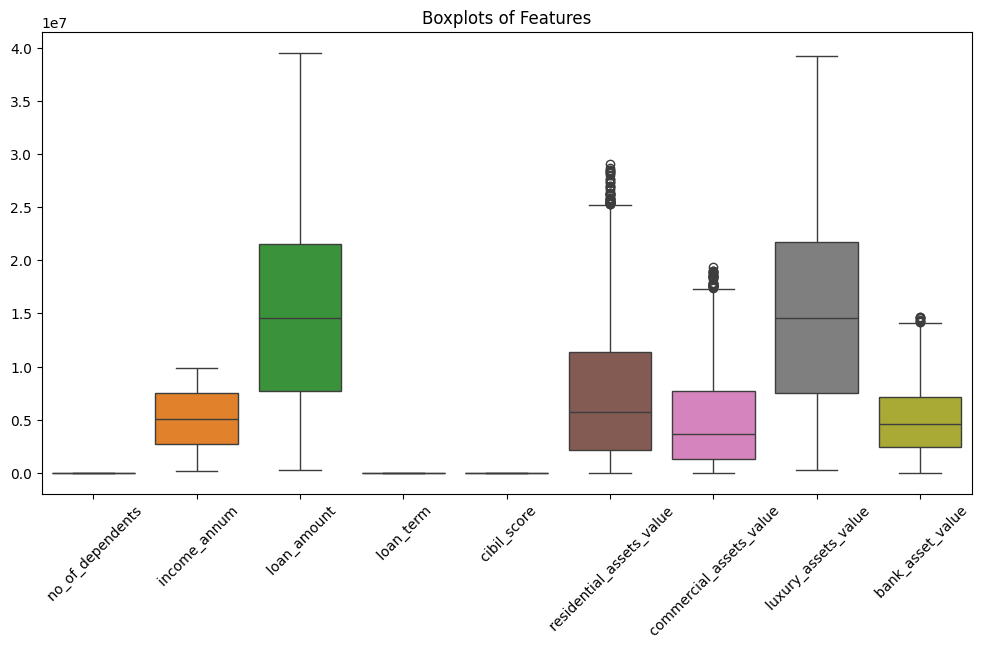

In [27]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data1)
plt.xticks(rotation=45)
plt.title("Boxplots of Features")
plt.show()

In [28]:
dependents_fig = px.box(data1, y=' no_of_dependents')
dependents_fig.show()

In [29]:
education_fig = px.box(data1, x=' education')
education_fig.show()

In [30]:
self_employed_fig = px.box(data1, x=' self_employed')
self_employed_fig.show()

In [31]:
income_annum_fig = px.box(data1, y=' income_annum')
income_annum_fig.show()

In [32]:
loan_term_fig = px.box(data1, y=' loan_term')
loan_term_fig.show()

In [33]:
cibil_score_fig = px.box(data1, y=' cibil_score')
cibil_score_fig.show()

In [34]:
residential_assets_value_fig = px.box(data1, y=' residential_assets_value')
residential_assets_value_fig.show()

In [35]:
commercial_assets_value_fig = px.box(data1, y=' commercial_assets_value')
commercial_assets_value_fig.show()

In [36]:
luxury_assets_value_fig = px.box(data1, y=' luxury_assets_value')
luxury_assets_value_fig.show()

In [37]:
bank_asset_value_fig = px.box(data1, y=' bank_asset_value')
bank_asset_value_fig.show()

In [38]:
loan_status_fig = px.box(data1, x=' loan_status')
loan_status_fig.show()

## imbalance ratio

In [39]:
#works out ratio for how many people are approved a loan compared to rejected
counts = data1[' loan_status'].value_counts()
imbalance_ratio = counts.max() / counts.min()
print(f"Imbalance Ratio: {imbalance_ratio:.2f}:1")

Imbalance Ratio: 1.65:1


## Checking the correlation of the data

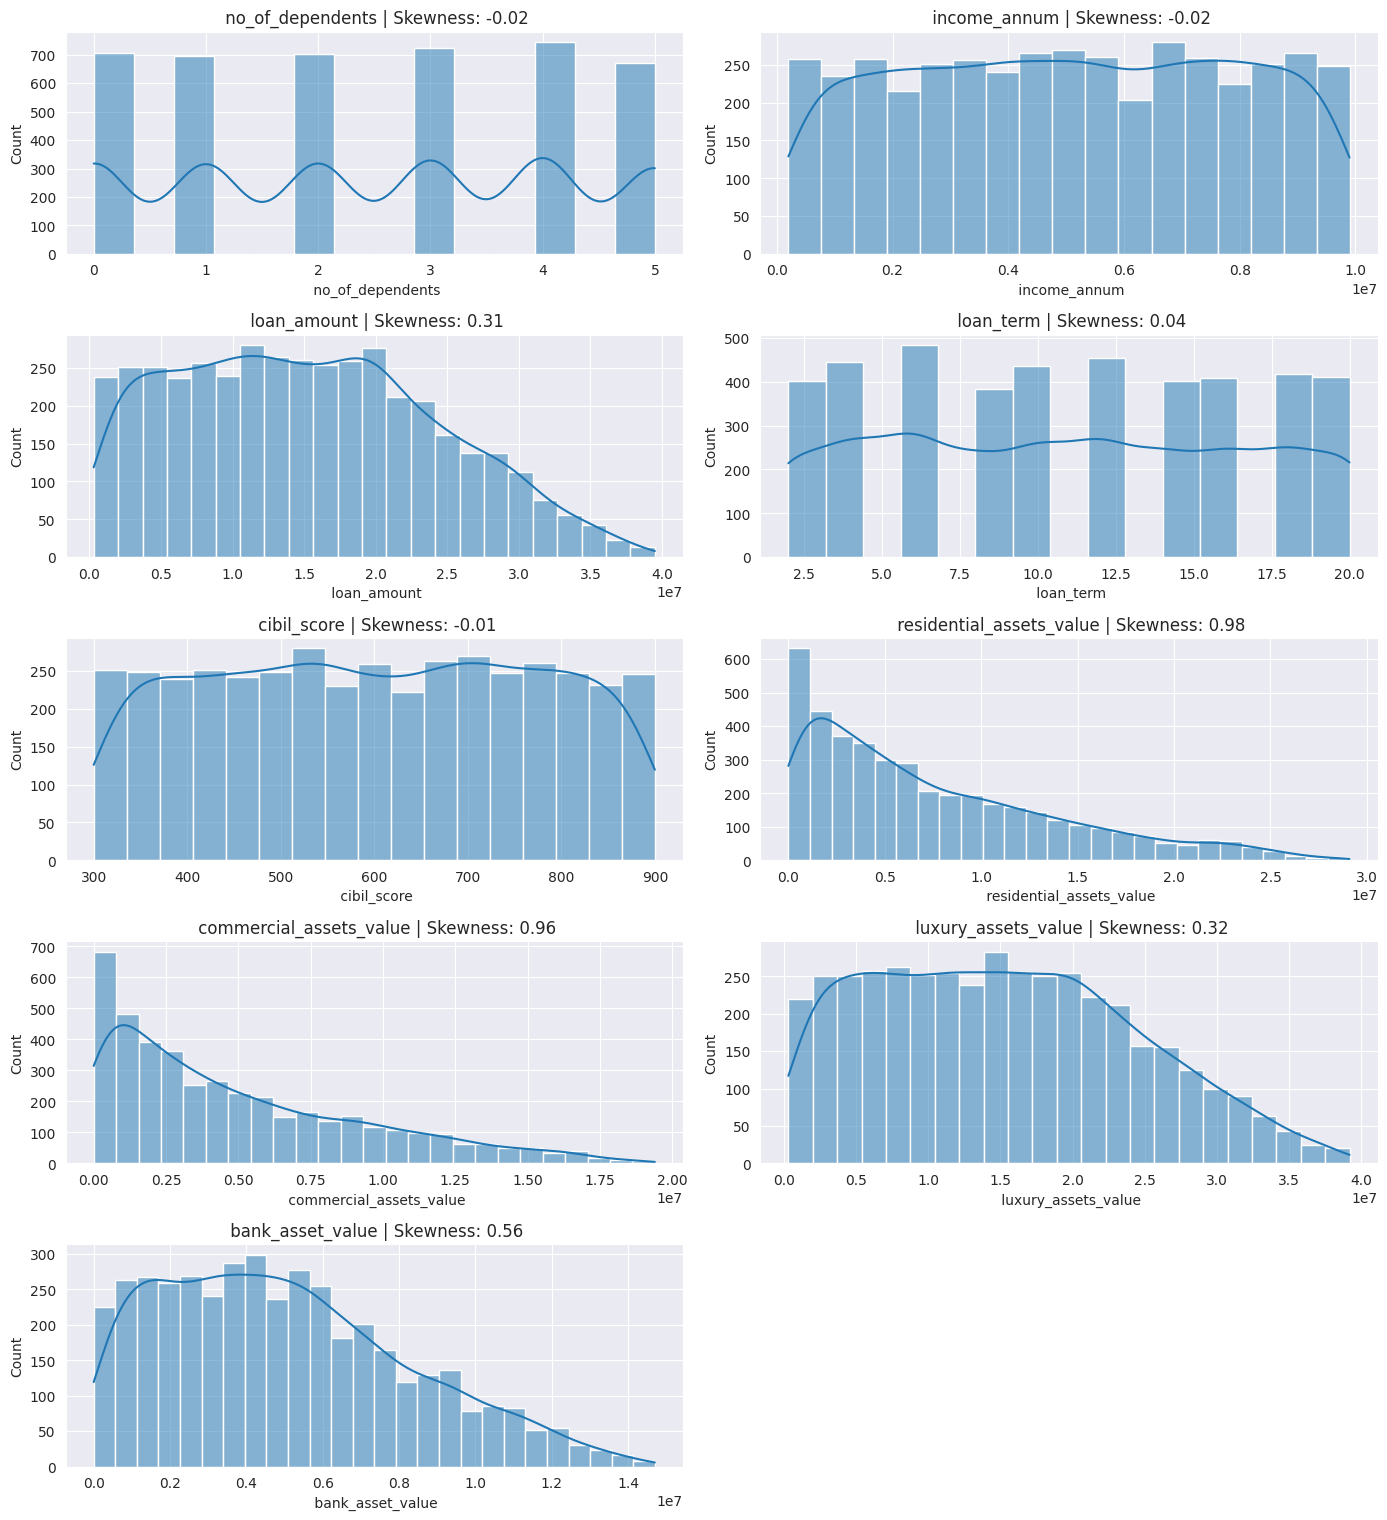

In [40]:
sns.set_style("darkgrid")

numerical_columns = data1.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(data1[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(data1[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

# Pair plots

<Figure size 1000x600 with 0 Axes>

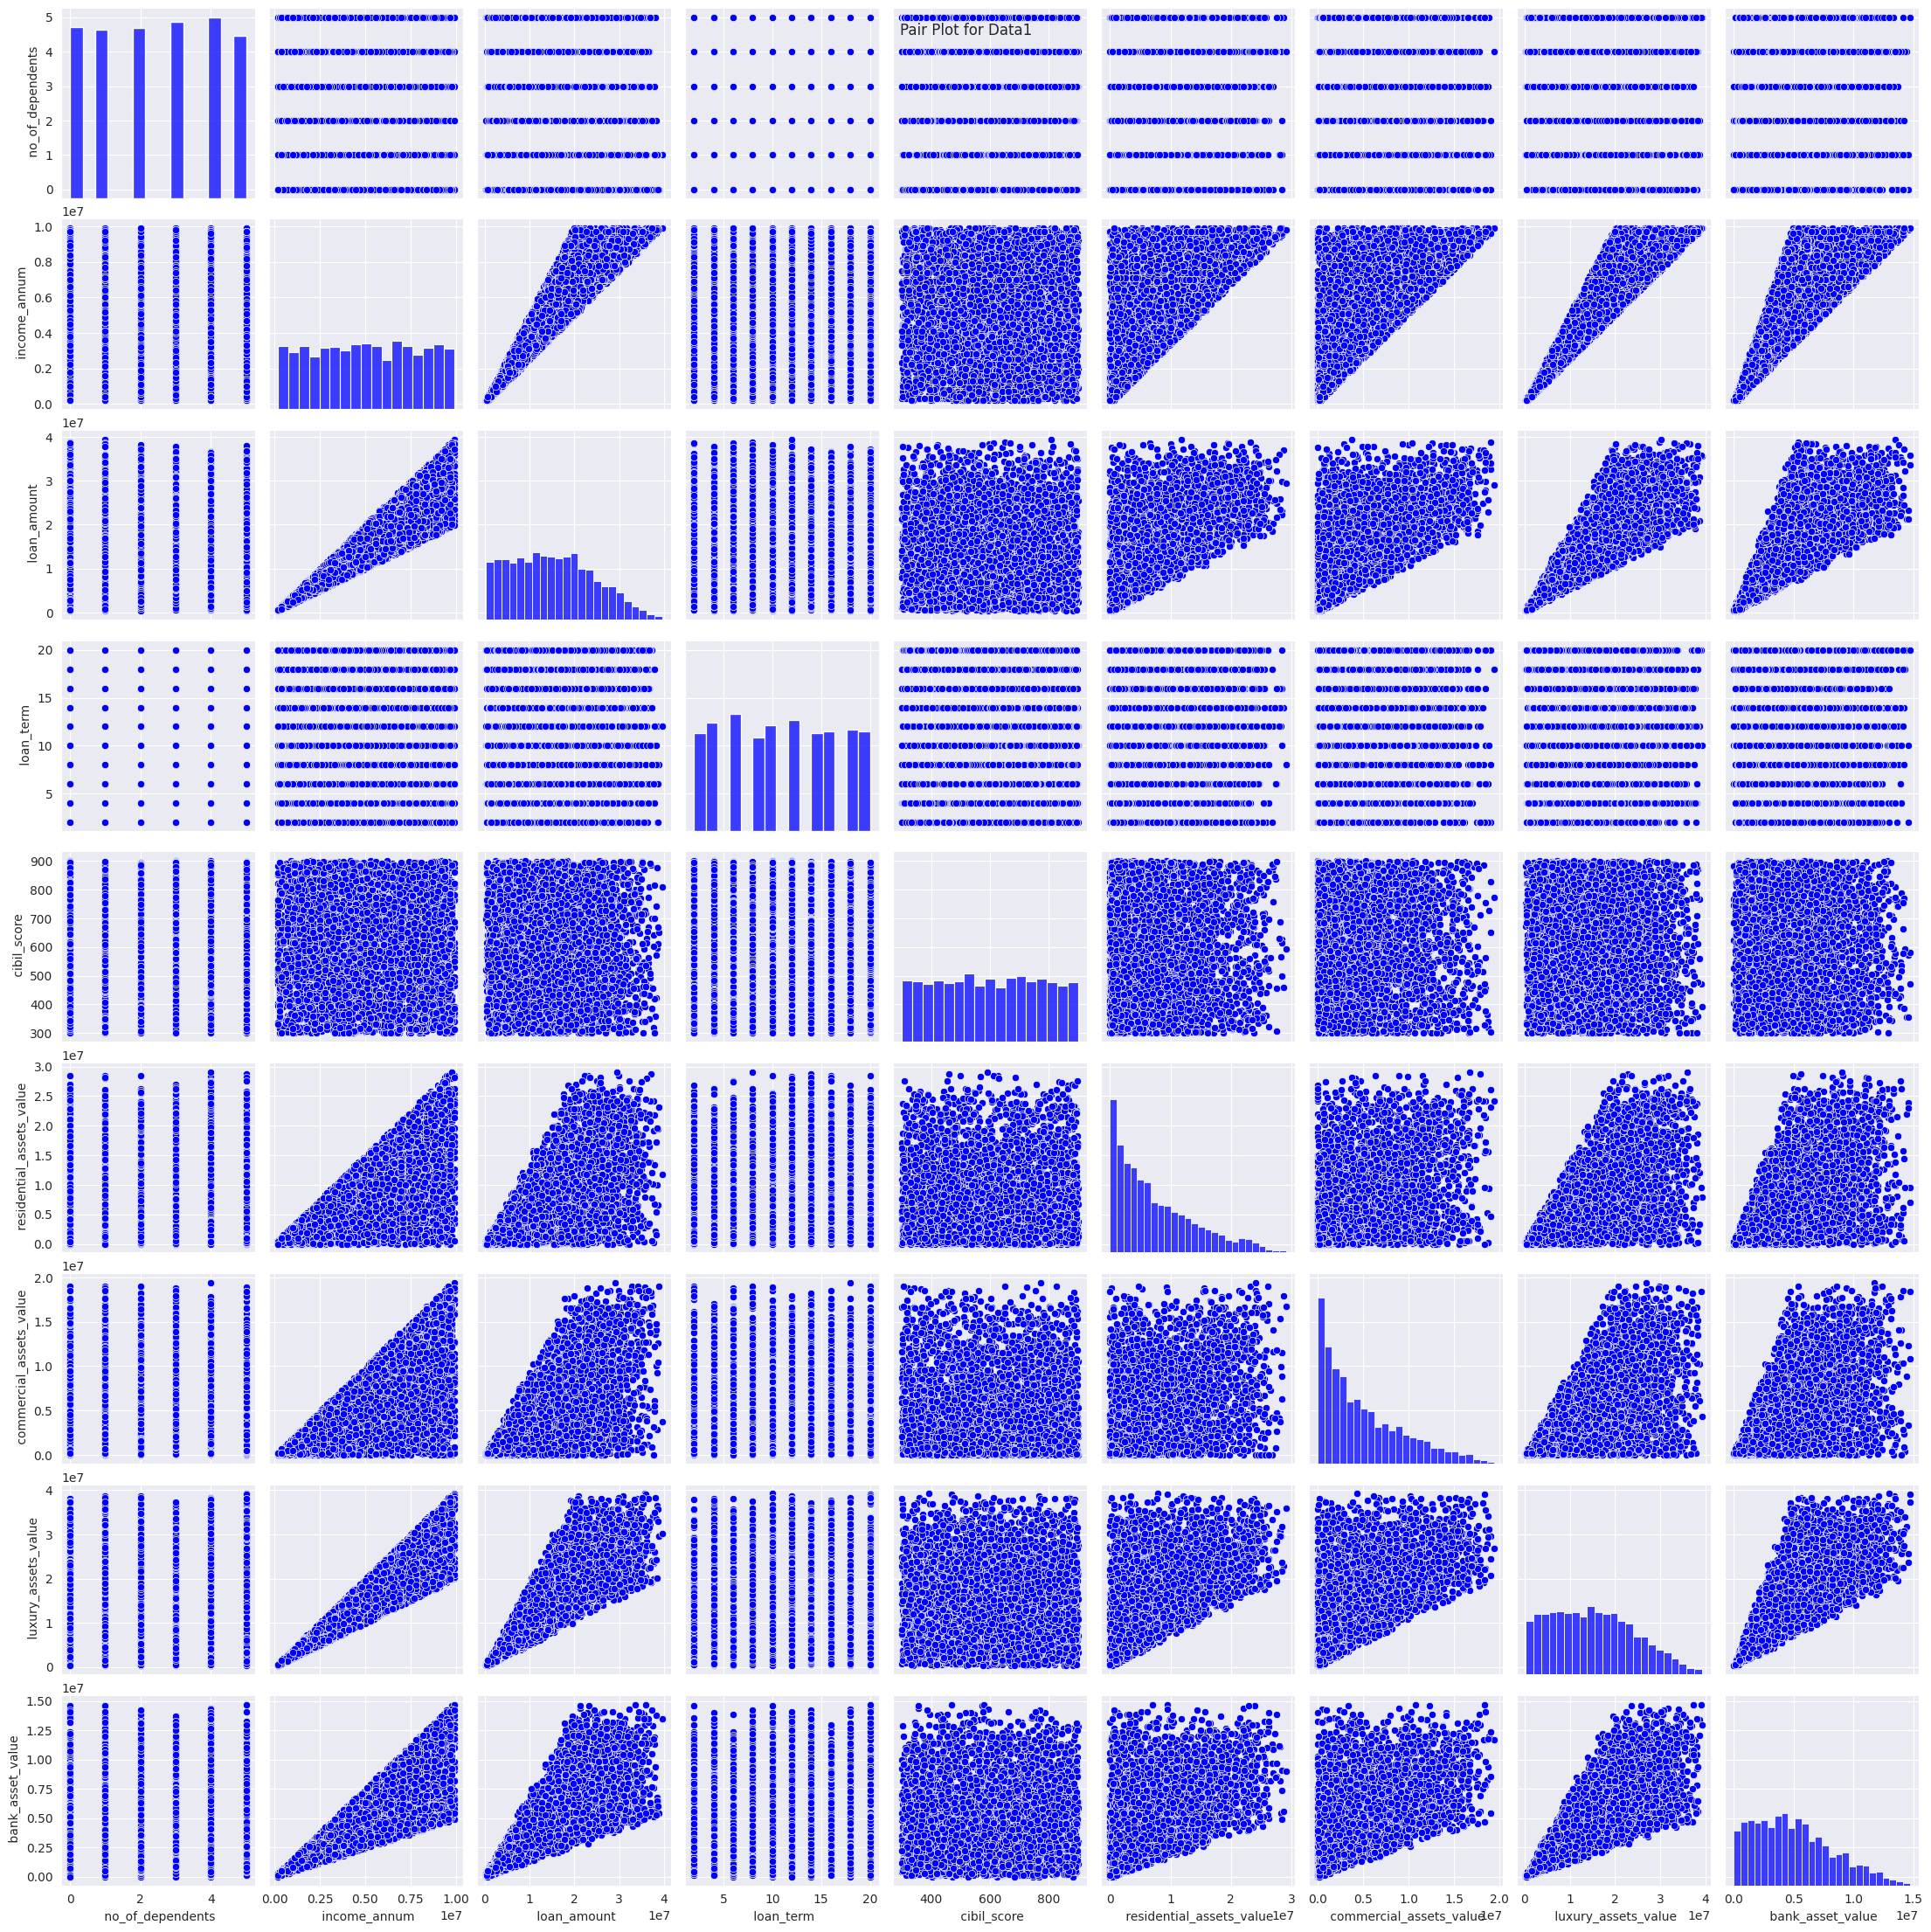

In [41]:
sns.set_palette(("blue","pink"))

plt.figure(figsize=(10, 6))

sns.pairplot(data1)

plt.suptitle('Pair Plot for Data1')
plt.show()

# Bar charts

In [42]:
loan_status1_fig = px.bar(data1, x=' loan_status')
loan_status1_fig.show()

In [43]:
education1_fig = px.bar(data1, x=' education')
education1_fig.show()

In [44]:
self_employed1_fig = px.bar(data1, x=' self_employed')
self_employed1_fig.show()

In [45]:
#no_of_dependents1_fig = px.bar(data1, x=' no_of_dependents')
#no_of_dependents1_fig.show()

In [46]:
#income_annum1_fig = px.bar(data1, x=' income_annum')
#income_annum1_fig.show()

In [47]:
loan_amount1_fig = px.bar(data1, x=' loan_amount')
loan_amount1_fig.show()

In [48]:
#loan_term1_fig = px.bar(data1, x=' loan_term')
#loan_term1_fig.show()

In [49]:
cibil_score1_fig = px.bar(data1, x=' cibil_score')
cibil_score1_fig.show()

In [50]:
#residential_assets_value1_fig = px.bar(data1, x=' residential_assets_value')
#residential_assets_value1_fig.show()

In [51]:
#commercial_assets_value1_fig = px.bar(data1, x=' commercial_assets_value')
#commercial_assets_value1_fig.show()

In [52]:
#luxury_assets_value1_fig = px.bar(data1, x=' luxury_assets_value')
#luxury_assets_value1_fig.show()

In [53]:
#bank_asset_value1_fig = px.bar(data1, x=' bank_asset_value')
#bank_asset_value1_fig.show()

# REMOVING OUTLIERS

In [54]:
#this is a in built function that detects outliers using IQR
#returns the outliers at the end

def find_outliers_IQR(data):

  q1=data.quantile(0.25)

  q3=data.quantile(0.75)

  IQR=q3-q1

  outliers = data[((data<(q1-1.5*IQR))|(data> (q3+1.5*IQR)))]

  return outliers

In [55]:
#have called outliers by using a function from a numeric variable
#called outliers to the screen
no_of_dependents_outliers = find_outliers_IQR(data1[' no_of_dependents'])

print("number of outliers: "+ str(len(no_of_dependents_outliers)))

no_of_dependents_outliers

number of outliers: 0


,no_of_dependents


In [56]:
#have called outliers by using a function from a numeric variable
#called outliers to the screen
income_annum_outliers = find_outliers_IQR(data1[' income_annum'])

print("number of outliers: "+ str(len(income_annum_outliers)))

income_annum_outliers

number of outliers: 0


,income_annum


In [57]:
#have called outliers by using a function from a numeric variable
#called outliers to the screen
loan_amount_outliers = find_outliers_IQR(data1[' loan_amount'])

print("number of outliers: "+ str(len(loan_amount_outliers)))

loan_amount_outliers

number of outliers: 0


,loan_amount


In [58]:
#have called outliers by using a function from a numeric variable
#called outliers to the screen
loan_term_outliers = find_outliers_IQR(data1[' loan_term'])

print("number of outliers: "+ str(len(loan_term_outliers)))

loan_term_outliers

number of outliers: 0


,loan_term


In [59]:
#have called outliers by using a function from a numeric variable
#called outliers to the screen
cibil_score_outliers = find_outliers_IQR(data1[' cibil_score'])

print("number of outliers: "+ str(len(cibil_score_outliers)))

cibil_score_outliers

number of outliers: 0


,cibil_score


In [60]:
#have called outliers by using a function from a numeric variable
#called outliers to the screen
residential_assets_value_outliers = find_outliers_IQR(data1[' residential_assets_value'])

print("number of outliers: "+ str(len(residential_assets_value_outliers)))

residential_assets_value_outliers

number of outliers: 47


,residential_assets_value
82,25500000
98,25900000
123,26800000
228,25500000
262,25600000
693,25400000
714,28300000
781,26300000
892,27600000
905,28700000


In [61]:
#removing all outliers from residential assets value
#data1.drop(data1.index[[82,98,123,228,262,693,714,781,892,905,919,924,953,956,987,1002,1397,1419,1468,1591,1625,1965,1997,2185,2318,2384,2412,2586,2715,2818,2828,2927,2930,2940,3119,3157,3234,3498,3631,3763,3782,3868,3872,3880,4042,4074]], inplace=True)

In [62]:
# error message index 4237 is out of bounds for axis 0 with size 4102

In [63]:
#have called outliers by using a function from a numeric variable
#called outliers to the screen
commercial_assets_value_outliers = find_outliers_IQR(data1[' commercial_assets_value'])

print("number of outliers: "+ str(len(commercial_assets_value_outliers)))

commercial_assets_value_outliers

number of outliers: 32


,commercial_assets_value
0,17600000
157,18700000
231,17500000
258,19000000
367,18500000
554,18800000
791,17800000
895,18500000
905,17900000
1029,18300000


In [64]:
#removing all outliers from commercial assets value
#data1.drop(data1.index[[0,157,231,258,232,367,554,791,895,905,1029,1131,1194,1254,1272,1304,1609,1761,1768,1812,2004,2302,2349,2914,2933,2940,2976,3000,3439,3541,3790,3882,3949,4010]], inplace=True)

In [65]:
#couldnt remove outliers 4120,4205

In [66]:
#have called outliers by using a function from a numeric variable
#called outliers to the screen
luxury_assets_value_outliers = find_outliers_IQR(data1[' luxury_assets_value'])

print("number of outliers: "+ str(len(luxury_assets_value_outliers)))

luxury_assets_value_outliers

number of outliers: 0


,luxury_assets_value


In [67]:
#have called outliers by using a function from a numeric variable
#called outliers to the screen
bank_asset_value_outliers = find_outliers_IQR(data1[' bank_asset_value'])

print("number of outliers: "+ str(len(bank_asset_value_outliers)))

bank_asset_value_outliers

number of outliers: 8


,bank_asset_value
200,14400000
1272,14700000
1633,14600000
1674,14600000
1805,14700000
1818,14300000
2028,14200000
4191,14200000


In [68]:
#removing all outliers from bank asset value
#data1.drop(data1.index[[200,1272,1633,1674,1805,1818,2028]], inplace=True)

In [69]:
# couldnt remove outlier 4191

In [70]:
data1.shape

(4241, 12)

## LABEL ENCODING

In [71]:
#importing more relevant libraies
from sklearn import preprocessing

label_encoder = preprocessing.LabelEncoder()

In [72]:
#again referncing back to code earlier which showed me data types i have selected a variable that is an object type
label_encoder = preprocessing.LabelEncoder()
data1[' no_of_dependents']= label_encoder.fit_transform(data1[' no_of_dependents'])
data1[' income_annum'] = label_encoder.fit_transform(data1[' income_annum'])
data1[' loan_amount'] = label_encoder.fit_transform(data1[' loan_amount'])
data1[' loan_term'] = label_encoder.fit_transform(data1[' loan_term'])
data1[' cibil_score'] = label_encoder.fit_transform(data1[' cibil_score'])
data1[' residential_assets_value'] = label_encoder.fit_transform(data1[' residential_assets_value'])
data1[' commercial_assets_value'] = label_encoder.fit_transform(data1[' commercial_assets_value'])
data1[' luxury_assets_value'] = label_encoder.fit_transform(data1[' luxury_assets_value'])
data1[' bank_asset_value'] = label_encoder.fit_transform(data1[' bank_asset_value'])
data1[' loan_status'] = data1[' loan_status'].map({' Approved': 1 , ' Rejected' : 2 })
data1[' education'] = data1[' education'].map({' Graduate': 1 , ' Not Graduate' : 2 })
data1[' self_employed'] = data1[' self_employed'].map({' Yes': 1 , ' No' : 2 })

In [73]:
data1.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,2,94,296,5,478,24,175,224,80,1
1,0,2,1,39,119,3,117,27,22,85,33,2
2,3,1,2,89,294,9,206,71,45,330,127,2
3,3,1,2,80,304,3,167,182,33,230,79,2
4,5,2,1,96,239,9,82,124,82,291,50,2


# Buidling models

In [74]:
#!pip install git+https://github.com/pycaret/pycaret.git@master

In [75]:
data1.shape

(4241, 12)

In [78]:
#saving my work
#change name of file
data1.to_csv(r'Cleaned Dataset1.csv', index=False)